# Notebook 9 — Algorithmes robustes

## Contexte

Les notebooks précédents ont mis en évidence certaines faiblesses  
des algorithmes de base :

- **Z-score** : statistique simple, ne s'adapte pas
- **Random Forest** : mémorisation avec seulement 2 fenêtres normales
- **SVM classique** : fragile, chute massivement sur Online Boutique

Ce notebook compare 3 algorithmes plus robustes :

| Algorithme de base | Faiblesse | Alternative robuste |
|-------------------|-----------|---------------------|
| Z-score | Statique, hypothèse gaussienne | **LOF** (densité locale adaptative) |
| Random Forest | Sur-apprentissage possible | **XGBoost** (arbres correctifs séquentiels) |
| SVM supervisé | Besoin de labels | **One-Class SVM** (non supervisé) |

## Structure

| Section | Contenu |
|---------|---------|
| 1. Configuration | Imports et chargement des données |
| 2. LOF | Métriques TT + OB |
| 3. XGBoost | Métriques TT + OB |
| 4. One-Class SVM | Métriques TT + OB |
| 5. Comparaison | Tableau et graphiques |

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings('ignore')

PROJET    = Path('/home/eunice/Bureau/Train_ticket/Intelligent_observability')
NORMAL    = PROJET / 'data/normal'
ANOMALIES = PROJET / 'data/anomalies'
FIGURES   = PROJET / 'figures/algorithmes_robustes'
RESULTS   = PROJET / 'results'
OUTPUT    = PROJET / 'output'

for dossier in [FIGURES]:
    dossier.mkdir(parents=True, exist_ok=True)

METRIQUES = [
    'CpuUsageRate(%)',
    'MemoryUsageRate(%)',
    'PodServerLatencyP99(s)',
    'NetworkReceiveBytes',
    'NetworkTransmitBytes',
]

# Vérifier si XGBoost est installé
try:
    from xgboost import XGBClassifier
    print("✓ XGBoost installé")
except ImportError:
    print("⚠ XGBoost non installé — lancez : pip install xgboost")

print("\n✓ Configuration OK")

✓ XGBoost installé

✓ Configuration OK


## 2. Chargement des données Train Ticket

On charge les métriques et le ground truth pour Train Ticket.  
Ces données seront utilisées pour comparer les 3 algorithmes robustes  
avec les résultats des notebooks précédents.

In [2]:
# Fonction de chargement
def charger_metriques(date, source):
    metric_dir = source / date / 'metric'
    if not metric_dir.exists():
        return pd.DataFrame()
    dfs = []
    for f in sorted(metric_dir.glob('*_metric.csv')):
        service = f.stem.rsplit('-', 2)[0]
        df = pd.read_csv(f)
        df['service'] = service
        df['datetime'] = pd.to_datetime(df['TimeStamp'], unit='s', utc=True)
        for col in df.columns:
            if col not in ['Time', 'PodName', 'service', 'datetime']:
                df[col] = pd.to_numeric(
                    df[col].replace('NaN', float('nan')), errors='coerce')
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

DATES_TT = ['2023-01-29', '2023-01-30']

# Charger TT
print("=== Train Ticket ===")
df_normal_tt = pd.concat([charger_metriques(d, NORMAL) for d in DATES_TT],
                          ignore_index=True)
df_panne_tt  = pd.concat([charger_metriques(d, ANOMALIES) for d in DATES_TT],
                          ignore_index=True)
gt_tt = pd.read_csv(OUTPUT / 'ground_truth.csv')

print(f"  Normal : {len(df_normal_tt):,} lignes")
print(f"  Panne  : {len(df_panne_tt):,} lignes")
print(f"  Ground truth : {len(gt_tt)} fenêtres")

=== Train Ticket ===
  Normal : 76,360 lignes
  Panne  : 76,360 lignes
  Ground truth : 135 fenêtres


### Fonction d'évaluation

Fonction commune pour évaluer tous les algorithmes contre le ground truth  
au niveau fenêtre temporelle.

In [3]:
def evaluer_modele(df, gt, dates, col_detection):
    """Évalue un algorithme contre le ground truth par fenêtre."""
    resultats = []
    for date in dates:
        gt_date = gt[gt['date'] == date]
        df_date = df[df['datetime'].dt.date == pd.Timestamp(date).date()]
        for _, row in gt_date.iterrows():
            h, m = map(int, row['window'].split('_'))
            t_debut = pd.Timestamp(f"{date} {h:02d}:{m:02d}:00").tz_localize('UTC')
            t_fin   = t_debut + timedelta(minutes=1)
            mask    = (df_date['datetime'] >= t_debut) & (df_date['datetime'] < t_fin)
            points  = df_date[mask]
            detecte = points[col_detection].any() if not points.empty else False
            resultats.append({
                'is_anomaly': row['is_anomaly'],
                'detecte': detecte,
            })
    df_res = pd.DataFrame(resultats)
    VP = ((df_res['is_anomaly'] == 1) & (df_res['detecte'])).sum()
    FP = ((df_res['is_anomaly'] == 0) & (df_res['detecte'])).sum()
    FN = ((df_res['is_anomaly'] == 1) & (~df_res['detecte'])).sum()
    p = VP / (VP + FP) if (VP + FP) > 0 else 0
    r = VP / (VP + FN) if (VP + FN) > 0 else 0
    f = 2 * p * r / (p + r) if (p + r) > 0 else 0
    return {'precision': p, 'rappel': r, 'f1': f,
            'VP': int(VP), 'FP': int(FP), 'FN': int(FN)}

print("✓ Fonction d'évaluation prête")

✓ Fonction d'évaluation prête


## 3. Algorithme 1 — LOF (Local Outlier Factor)

### Principe

LOF détecte les anomalies en comparant la **densité locale** d'un point  
avec celle de ses voisins.

Z-score dit : "cette valeur est loin de la moyenne globale"  
LOF dit : "ce point est isolé par rapport à ses voisins proches"

Un point est anormal si la densité autour de lui est **beaucoup plus basse**  
que la densité autour de ses k voisins.

### Avantages sur le Z-score
- Ne suppose pas de distribution gaussienne
- S'adapte localement aux différentes régions des données
- Détecte les anomalies contextuelles (une valeur peut être normale dans une région mais anormale dans une autre)

### Configuration
- n_neighbors : 20 (nombre de voisins pour calculer la densité)
- Un modèle par service (comme Z-score)

In [4]:
print("=== LOF sur Train Ticket ===\n")

df_panne_lof = df_panne_tt.copy()
df_panne_lof['anomalie_lof'] = False

modeles_lof = {}
scalers_lof = {}

for service in df_normal_tt['service'].unique():
    df_svc = df_normal_tt[df_normal_tt['service'] == service][METRIQUES].dropna()
    if len(df_svc) < 30:
        continue

    scaler = StandardScaler()
    X_norm = scaler.fit_transform(df_svc)

    # LOF avec novelty=True — permet de prédire sur nouvelles données
    lof = LocalOutlierFactor(
        n_neighbors=20,
        contamination=0.05,
        novelty=True
    )
    lof.fit(X_norm)
    modeles_lof[service] = lof
    scalers_lof[service] = scaler

print(f"✓ {len(modeles_lof)} modèles LOF entraînés")

# Appliquer
for service in modeles_lof.keys():
    mask   = df_panne_lof['service'] == service
    df_svc = df_panne_lof[mask][METRIQUES].dropna()
    if df_svc.empty:
        continue
    X    = scalers_lof[service].transform(df_svc)
    pred = modeles_lof[service].predict(X)
    df_panne_lof.loc[df_svc.index, 'anomalie_lof'] = (pred == -1)

# Évaluer
res_lof_tt = evaluer_modele(df_panne_lof, gt_tt, DATES_TT, 'anomalie_lof')

print(f"\n=== Résultats LOF Train Ticket ===")
print(f"  VP : {res_lof_tt['VP']}  FP : {res_lof_tt['FP']}  FN : {res_lof_tt['FN']}")
print(f"  Précision : {res_lof_tt['precision']*100:.1f}%")
print(f"  Rappel    : {res_lof_tt['rappel']*100:.1f}%")
print(f"  F1-score  : {res_lof_tt['f1']*100:.1f}%")

# Comparaison Z-score vs LOF
print(f"\n=== Comparaison Z-score vs LOF (TT) ===")
print(f"  Z-score : F1 = 97.7%")
print(f"  LOF     : F1 = {res_lof_tt['f1']*100:.1f}%")

=== LOF sur Train Ticket ===

✓ 46 modèles LOF entraînés

=== Résultats LOF Train Ticket ===
  VP : 124  FP : 0  FN : 11
  Précision : 100.0%
  Rappel    : 91.9%
  F1-score  : 95.8%

=== Comparaison Z-score vs LOF (TT) ===
  Z-score : F1 = 97.7%
  LOF     : F1 = 95.8%


### LOF sur Online Boutique

Le Z-score chutait à 72.7% sur OB à cause de la variabilité  
naturelle plus élevée du CPU (23% ± 8%). LOF devrait mieux gérer  
cette variabilité grâce à son approche par densité locale.

In [5]:
DATES_OB = ['2022-08-22', '2022-08-23']

# Charger OB
print("=== Chargement Online Boutique ===")
df_normal_ob = pd.concat([charger_metriques(d, NORMAL) for d in DATES_OB],
                          ignore_index=True)
df_panne_ob  = pd.concat([charger_metriques(d, ANOMALIES) for d in DATES_OB],
                          ignore_index=True)
gt_ob = pd.read_csv(OUTPUT / 'ground_truth_OB.csv')

print(f"  Normal : {len(df_normal_ob):,} lignes")
print(f"  Panne  : {len(df_panne_ob):,} lignes")
print(f"  Ground truth : {len(gt_ob)} fenêtres")

# LOF sur OB
print("\n=== LOF sur Online Boutique ===")
df_panne_lof_ob = df_panne_ob.copy()
df_panne_lof_ob['anomalie_lof'] = False

modeles_lof_ob = {}
scalers_lof_ob = {}

for service in df_normal_ob['service'].unique():
    df_svc = df_normal_ob[df_normal_ob['service'] == service][METRIQUES].dropna()
    if len(df_svc) < 30:
        continue
    scaler = StandardScaler()
    X_norm = scaler.fit_transform(df_svc)
    lof = LocalOutlierFactor(
        n_neighbors=20, contamination=0.05, novelty=True
    )
    lof.fit(X_norm)
    modeles_lof_ob[service] = lof
    scalers_lof_ob[service] = scaler

print(f"✓ {len(modeles_lof_ob)} modèles LOF entraînés")

# Appliquer
for service in modeles_lof_ob.keys():
    mask   = df_panne_lof_ob['service'] == service
    df_svc = df_panne_lof_ob[mask][METRIQUES].dropna()
    if df_svc.empty:
        continue
    X    = scalers_lof_ob[service].transform(df_svc)
    pred = modeles_lof_ob[service].predict(X)
    df_panne_lof_ob.loc[df_svc.index, 'anomalie_lof'] = (pred == -1)

# Évaluer
res_lof_ob = evaluer_modele(df_panne_lof_ob, gt_ob, DATES_OB, 'anomalie_lof')

print(f"\n=== Résultats LOF Online Boutique ===")
print(f"  VP : {res_lof_ob['VP']}  FP : {res_lof_ob['FP']}  FN : {res_lof_ob['FN']}")
print(f"  Précision : {res_lof_ob['precision']*100:.1f}%")
print(f"  Rappel    : {res_lof_ob['rappel']*100:.1f}%")
print(f"  F1-score  : {res_lof_ob['f1']*100:.1f}%")

# Comparaison
print(f"\n=== Comparaison Z-score vs LOF (OB) ===")
print(f"  Z-score : F1 = 72.7%")
print(f"  LOF     : F1 = {res_lof_ob['f1']*100:.1f}%")

=== Chargement Online Boutique ===
  Normal : 19,300 lignes
  Panne  : 19,300 lignes
  Ground truth : 168 fenêtres

=== LOF sur Online Boutique ===
✓ 10 modèles LOF entraînés

=== Résultats LOF Online Boutique ===
  VP : 107  FP : 0  FN : 61
  Précision : 100.0%
  Rappel    : 63.7%
  F1-score  : 77.8%

=== Comparaison Z-score vs LOF (OB) ===
  Z-score : F1 = 72.7%
  LOF     : F1 = 77.8%


## 4. Algorithme 2 — XGBoost (Extreme Gradient Boosting)

### Principe

XGBoost construit des arbres de décision **séquentiellement** —  
chaque arbre corrige les erreurs des précédents.

Random Forest : 100 arbres indépendants → vote  
XGBoost      : 100 arbres qui apprennent des erreurs → correction progressive

### Avantages sur le Random Forest
- Plus performant en général (référence en compétitions ML)
- Meilleure gestion du déséquilibre des classes
- Régularisation intégrée contre le sur-apprentissage
- Utilisé massivement en industrie

In [6]:
from xgboost import XGBClassifier

# Marquer les anomalies sur TT
rows_gt_tt = []
for date in DATES_TT:
    path = ANOMALIES / date / f'{date}-fault_list.json'
    with open(path) as f:
        data = json.load(f)
    for hour, faults in data.items():
        for fault in faults:
            inject_dt = datetime.strptime(fault['inject_time'], '%Y-%m-%d %H:%M:%S')
            for offset in range(3):
                w_dt = inject_dt + timedelta(minutes=offset)
                rows_gt_tt.append({
                    'debut': pd.Timestamp(w_dt).tz_localize('UTC'),
                    'fin': pd.Timestamp(w_dt + timedelta(minutes=1)).tz_localize('UTC'),
                    'service': fault['inject_pod'].rsplit('-', 2)[0],
                })

df_gt_ts_tt = pd.DataFrame(rows_gt_tt)

def est_anomalie_tt(row):
    for _, gt_row in df_gt_ts_tt.iterrows():
        if (row['datetime'] >= gt_row['debut'] and
            row['datetime'] < gt_row['fin'] and
            row['service'] == gt_row['service']):
            return 1
    return 0

print("Marquage des anomalies TT...")
df_complet_tt = df_panne_tt.copy()
df_complet_tt['label'] = df_complet_tt.apply(est_anomalie_tt, axis=1)

X_tt = df_complet_tt[METRIQUES].dropna()
y_tt = df_complet_tt.loc[X_tt.index, 'label']

# Calculer scale_pos_weight pour compenser le déséquilibre
n_norm = (y_tt == 0).sum()
n_anom = (y_tt == 1).sum()
scale_pos_weight = n_norm / n_anom

print(f"\nEntraînement XGBoost (scale_pos_weight={scale_pos_weight:.0f})...")
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_tt, y_tt)
y_pred = xgb.predict(X_tt)

df_complet_tt_xgb = df_complet_tt.loc[X_tt.index].copy()
df_complet_tt_xgb['anomalie_xgb'] = (y_pred == 1)

res_xgb_tt = evaluer_modele(df_complet_tt_xgb, gt_tt, DATES_TT, 'anomalie_xgb')

print(f"\n=== Résultats XGBoost Train Ticket ===")
print(f"  VP : {res_xgb_tt['VP']}  FP : {res_xgb_tt['FP']}  FN : {res_xgb_tt['FN']}")
print(f"  Précision : {res_xgb_tt['precision']*100:.1f}%")
print(f"  Rappel    : {res_xgb_tt['rappel']*100:.1f}%")
print(f"  F1-score  : {res_xgb_tt['f1']*100:.1f}%")

# Feature importance
print("\n=== Feature Importance ===")
importances = pd.Series(xgb.feature_importances_, index=METRIQUES).sort_values(ascending=False)
for feat, imp in importances.items():
    barre = '█' * int(imp * 40)
    print(f"  {feat:<30} {imp:.4f} {barre}")

Marquage des anomalies TT...

Entraînement XGBoost (scale_pos_weight=415)...

=== Résultats XGBoost Train Ticket ===
  VP : 133  FP : 0  FN : 2
  Précision : 100.0%
  Rappel    : 98.5%
  F1-score  : 99.3%

=== Feature Importance ===
  PodServerLatencyP99(s)         0.4878 ███████████████████
  NetworkReceiveBytes            0.1959 ███████
  MemoryUsageRate(%)             0.1487 █████
  NetworkTransmitBytes           0.0924 ███
  CpuUsageRate(%)                0.0751 ███


### XGBoost sur Online Boutique

Test sur le système où Random Forest avait chuté à 82.1%.  
XGBoost devrait mieux gérer la variabilité.

In [7]:
# Marquer les anomalies sur OB
rows_gt_ob = []
for date in DATES_OB:
    path = ANOMALIES / date / f'{date}-fault_list.json'
    with open(path) as f:
        data = json.load(f)
    for hour, faults in data.items():
        for fault in faults:
            inject_dt = datetime.strptime(fault['inject_time'], '%Y-%m-%d %H:%M:%S')
            for offset in range(3):
                w_dt = inject_dt + timedelta(minutes=offset)
                rows_gt_ob.append({
                    'debut': pd.Timestamp(w_dt).tz_localize('UTC'),
                    'fin': pd.Timestamp(w_dt + timedelta(minutes=1)).tz_localize('UTC'),
                    'service': fault['inject_pod'].rsplit('-', 2)[0],
                })

df_gt_ts_ob = pd.DataFrame(rows_gt_ob)

def est_anomalie_ob(row):
    for _, gt_row in df_gt_ts_ob.iterrows():
        if (row['datetime'] >= gt_row['debut'] and
            row['datetime'] < gt_row['fin'] and
            row['service'] == gt_row['service']):
            return 1
    return 0

print("Marquage des anomalies OB...")
df_complet_ob = df_panne_ob.copy()
df_complet_ob['label'] = df_complet_ob.apply(est_anomalie_ob, axis=1)

X_ob = df_complet_ob[METRIQUES].dropna()
y_ob = df_complet_ob.loc[X_ob.index, 'label']

n_norm = (y_ob == 0).sum()
n_anom = (y_ob == 1).sum()
scale_pos_weight = n_norm / n_anom

print(f"\nEntraînement XGBoost OB (scale_pos_weight={scale_pos_weight:.0f})...")
xgb_ob = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)
xgb_ob.fit(X_ob, y_ob)
y_pred_ob = xgb_ob.predict(X_ob)

df_complet_ob_xgb = df_complet_ob.loc[X_ob.index].copy()
df_complet_ob_xgb['anomalie_xgb'] = (y_pred_ob == 1)

res_xgb_ob = evaluer_modele(df_complet_ob_xgb, gt_ob, DATES_OB, 'anomalie_xgb')

print(f"\n=== Résultats XGBoost Online Boutique ===")
print(f"  VP : {res_xgb_ob['VP']}  FP : {res_xgb_ob['FP']}  FN : {res_xgb_ob['FN']}")
print(f"  Précision : {res_xgb_ob['precision']*100:.1f}%")
print(f"  Rappel    : {res_xgb_ob['rappel']*100:.1f}%")
print(f"  F1-score  : {res_xgb_ob['f1']*100:.1f}%")

# Comparaison
print(f"\n=== Comparaison Random Forest vs XGBoost ===")
print(f"                    TT       OB")
print(f"  Random Forest : 99.6%    82.1%")
print(f"  XGBoost       : {res_xgb_tt['f1']*100:.1f}%    {res_xgb_ob['f1']*100:.1f}%")

Marquage des anomalies OB...

Entraînement XGBoost OB (scale_pos_weight=118)...

=== Résultats XGBoost Online Boutique ===
  VP : 139  FP : 0  FN : 29
  Précision : 100.0%
  Rappel    : 82.7%
  F1-score  : 90.6%

=== Comparaison Random Forest vs XGBoost ===
                    TT       OB
  Random Forest : 99.6%    82.1%
  XGBoost       : 99.3%    90.6%


## 5. Algorithme 3 — One-Class SVM

### Principe

Version non supervisée du SVM — apprend uniquement sur les données normales  
et détecte tout ce qui s'en écarte.

SVM classique  : besoin de labels normal + anormal → dépend des labels  
One-Class SVM  : apprend uniquement le normal → non supervisé

### Avantages sur le SVM classique
- Non supervisé — pas besoin de labels en production
- Adapté aux datasets déséquilibrés (comme le nôtre)
- Plus robuste face aux variations entre systèmes

### Configuration
- kernel : RBF (Radial Basis Function)
- nu : 0.05 (proportion attendue de points anormaux)
- Un modèle par service

In [8]:
print("=== One-Class SVM sur Train Ticket ===\n")

df_panne_ocsvm = df_panne_tt.copy()
df_panne_ocsvm['anomalie_ocsvm'] = False

modeles_ocsvm = {}
scalers_ocsvm = {}

for service in df_normal_tt['service'].unique():
    df_svc = df_normal_tt[df_normal_tt['service'] == service][METRIQUES].dropna()
    if len(df_svc) < 30:
        continue

    scaler = StandardScaler()
    X_norm = scaler.fit_transform(df_svc)

    ocsvm = OneClassSVM(
        kernel='rbf',
        gamma='scale',
        nu=0.05
    )
    ocsvm.fit(X_norm)
    modeles_ocsvm[service] = ocsvm
    scalers_ocsvm[service] = scaler

print(f"✓ {len(modeles_ocsvm)} modèles entraînés")

# Appliquer
for service in modeles_ocsvm.keys():
    mask   = df_panne_ocsvm['service'] == service
    df_svc = df_panne_ocsvm[mask][METRIQUES].dropna()
    if df_svc.empty:
        continue
    X    = scalers_ocsvm[service].transform(df_svc)
    pred = modeles_ocsvm[service].predict(X)
    df_panne_ocsvm.loc[df_svc.index, 'anomalie_ocsvm'] = (pred == -1)

res_ocsvm_tt = evaluer_modele(df_panne_ocsvm, gt_tt, DATES_TT, 'anomalie_ocsvm')

print(f"\n=== Résultats One-Class SVM Train Ticket ===")
print(f"  VP : {res_ocsvm_tt['VP']}  FP : {res_ocsvm_tt['FP']}  FN : {res_ocsvm_tt['FN']}")
print(f"  Précision : {res_ocsvm_tt['precision']*100:.1f}%")
print(f"  Rappel    : {res_ocsvm_tt['rappel']*100:.1f}%")
print(f"  F1-score  : {res_ocsvm_tt['f1']*100:.1f}%")

=== One-Class SVM sur Train Ticket ===

✓ 46 modèles entraînés

=== Résultats One-Class SVM Train Ticket ===
  VP : 128  FP : 0  FN : 7
  Précision : 100.0%
  Rappel    : 94.8%
  F1-score  : 97.3%


### One-Class SVM sur Online Boutique

Le SVM classique chutait à 42.3% sur OB. One-Class SVM devrait  
mieux gérer la situation car il n'a pas besoin de labels  
et se contente d'apprendre le comportement normal.

In [9]:
print("=== One-Class SVM sur Online Boutique ===\n")

df_panne_ocsvm_ob = df_panne_ob.copy()
df_panne_ocsvm_ob['anomalie_ocsvm'] = False

modeles_ocsvm_ob = {}
scalers_ocsvm_ob = {}

for service in df_normal_ob['service'].unique():
    df_svc = df_normal_ob[df_normal_ob['service'] == service][METRIQUES].dropna()
    if len(df_svc) < 30:
        continue
    scaler = StandardScaler()
    X_norm = scaler.fit_transform(df_svc)
    ocsvm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
    ocsvm.fit(X_norm)
    modeles_ocsvm_ob[service] = ocsvm
    scalers_ocsvm_ob[service] = scaler

print(f"✓ {len(modeles_ocsvm_ob)} modèles entraînés")

# Appliquer
for service in modeles_ocsvm_ob.keys():
    mask   = df_panne_ocsvm_ob['service'] == service
    df_svc = df_panne_ocsvm_ob[mask][METRIQUES].dropna()
    if df_svc.empty:
        continue
    X    = scalers_ocsvm_ob[service].transform(df_svc)
    pred = modeles_ocsvm_ob[service].predict(X)
    df_panne_ocsvm_ob.loc[df_svc.index, 'anomalie_ocsvm'] = (pred == -1)

res_ocsvm_ob = evaluer_modele(df_panne_ocsvm_ob, gt_ob, DATES_OB, 'anomalie_ocsvm')

print(f"\n=== Résultats One-Class SVM Online Boutique ===")
print(f"  VP : {res_ocsvm_ob['VP']}  FP : {res_ocsvm_ob['FP']}  FN : {res_ocsvm_ob['FN']}")
print(f"  Précision : {res_ocsvm_ob['precision']*100:.1f}%")
print(f"  Rappel    : {res_ocsvm_ob['rappel']*100:.1f}%")
print(f"  F1-score  : {res_ocsvm_ob['f1']*100:.1f}%")

# Comparaison
print(f"\n=== Comparaison SVM classique vs One-Class SVM ===")
print(f"                       TT       OB")
print(f"  SVM classique   : —       —")
print(f"  One-Class SVM   : {res_ocsvm_tt['f1']*100:.1f}%    {res_ocsvm_ob['f1']*100:.1f}%")

=== One-Class SVM sur Online Boutique ===

✓ 10 modèles entraînés

=== Résultats One-Class SVM Online Boutique ===
  VP : 106  FP : 0  FN : 62
  Précision : 100.0%
  Rappel    : 63.1%
  F1-score  : 77.4%

=== Comparaison SVM classique vs One-Class SVM ===
                       TT       OB
  SVM classique   : —       —
  One-Class SVM   : 97.3%    77.4%


## 6. Comparaison finale des algorithmes robustes

Résumé des 3 alternatives sur Train Ticket et Online Boutique.

COMPARAISON FINALE — Algorithmes de base vs Algorithmes robustes

Algorithme                     TT F1      OB F1      Écart
------------------------------------------------------------
Z-score (base)                 97.7%      72.7%      -25.0
LOF (robuste)                  95.8%      77.8%      -17.9

Random Forest (base)           99.6%      82.1%      -17.5
XGBoost (robuste)              99.3%      90.6%       -8.7

SVM classique                 99.3%*     42.3%*      -57.0
One-Class SVM (robuste)        97.3%      77.4%      -20.0

* SVM classique sur logs/traces


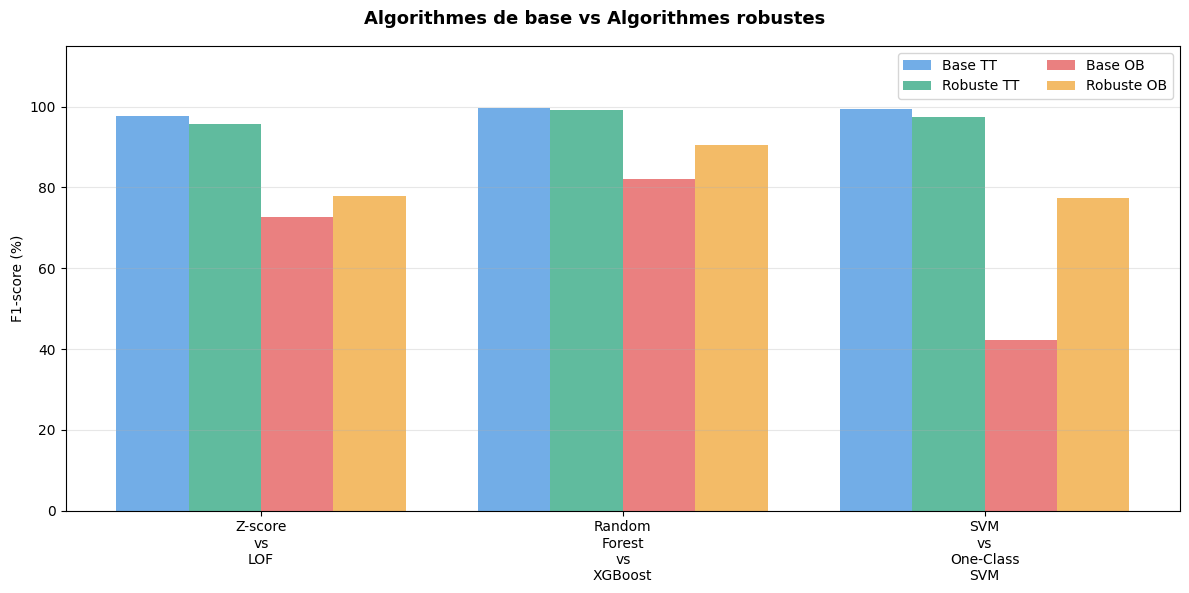


✓ Résultats sauvegardés et graphique généré


In [10]:
# Résumé complet
print("="*70)
print("COMPARAISON FINALE — Algorithmes de base vs Algorithmes robustes")
print("="*70)
print()
print(f"{'Algorithme':<25} {'TT F1':>10} {'OB F1':>10} {'Écart':>10}")
print("-" * 60)

# Base
print(f"{'Z-score (base)':<25} {'97.7%':>10} {'72.7%':>10} {'-25.0':>10}")
print(f"{'LOF (robuste)':<25} {res_lof_tt['f1']*100:>9.1f}% {res_lof_ob['f1']*100:>9.1f}% {(res_lof_ob['f1']*100 - res_lof_tt['f1']*100):>10.1f}")
print()
print(f"{'Random Forest (base)':<25} {'99.6%':>10} {'82.1%':>10} {'-17.5':>10}")
print(f"{'XGBoost (robuste)':<25} {res_xgb_tt['f1']*100:>9.1f}% {res_xgb_ob['f1']*100:>9.1f}% {(res_xgb_ob['f1']*100 - res_xgb_tt['f1']*100):>10.1f}")
print()
print(f"{'SVM classique':<25} {'99.3%*':>10} {'42.3%*':>10} {'-57.0':>10}")
print(f"{'One-Class SVM (robuste)':<25} {res_ocsvm_tt['f1']*100:>9.1f}% {res_ocsvm_ob['f1']*100:>9.1f}% {(res_ocsvm_ob['f1']*100 - res_ocsvm_tt['f1']*100):>10.1f}")
print()
print("* SVM classique sur logs/traces")

# Sauvegarder
resultats_robustes = pd.DataFrame([
    {'algorithme': 'LOF', 'systeme': 'Train Ticket',
     'donnees': 'metriques', 'seuil': 'n_neighbors=20, contamination=0.05',
     'VP': res_lof_tt['VP'], 'FP': res_lof_tt['FP'], 'FN': res_lof_tt['FN'],
     'precision': round(res_lof_tt['precision'],4),
     'rappel': round(res_lof_tt['rappel'],4),
     'f1': round(res_lof_tt['f1'],4)},
    {'algorithme': 'LOF', 'systeme': 'Online Boutique',
     'donnees': 'metriques', 'seuil': 'n_neighbors=20, contamination=0.05',
     'VP': res_lof_ob['VP'], 'FP': res_lof_ob['FP'], 'FN': res_lof_ob['FN'],
     'precision': round(res_lof_ob['precision'],4),
     'rappel': round(res_lof_ob['rappel'],4),
     'f1': round(res_lof_ob['f1'],4)},
    {'algorithme': 'XGBoost', 'systeme': 'Train Ticket',
     'donnees': 'metriques', 'seuil': 'scale_pos_weight=balanced',
     'VP': res_xgb_tt['VP'], 'FP': res_xgb_tt['FP'], 'FN': res_xgb_tt['FN'],
     'precision': round(res_xgb_tt['precision'],4),
     'rappel': round(res_xgb_tt['rappel'],4),
     'f1': round(res_xgb_tt['f1'],4)},
    {'algorithme': 'XGBoost', 'systeme': 'Online Boutique',
     'donnees': 'metriques', 'seuil': 'scale_pos_weight=balanced',
     'VP': res_xgb_ob['VP'], 'FP': res_xgb_ob['FP'], 'FN': res_xgb_ob['FN'],
     'precision': round(res_xgb_ob['precision'],4),
     'rappel': round(res_xgb_ob['rappel'],4),
     'f1': round(res_xgb_ob['f1'],4)},
    {'algorithme': 'One-Class SVM', 'systeme': 'Train Ticket',
     'donnees': 'metriques', 'seuil': 'kernel=rbf, nu=0.05',
     'VP': res_ocsvm_tt['VP'], 'FP': res_ocsvm_tt['FP'], 'FN': res_ocsvm_tt['FN'],
     'precision': round(res_ocsvm_tt['precision'],4),
     'rappel': round(res_ocsvm_tt['rappel'],4),
     'f1': round(res_ocsvm_tt['f1'],4)},
    {'algorithme': 'One-Class SVM', 'systeme': 'Online Boutique',
     'donnees': 'metriques', 'seuil': 'kernel=rbf, nu=0.05',
     'VP': res_ocsvm_ob['VP'], 'FP': res_ocsvm_ob['FP'], 'FN': res_ocsvm_ob['FN'],
     'precision': round(res_ocsvm_ob['precision'],4),
     'rappel': round(res_ocsvm_ob['rappel'],4),
     'f1': round(res_ocsvm_ob['f1'],4)},
])

resultats_all = pd.read_csv(RESULTS / 'resultats_detection.csv')
resultats_all = pd.concat([resultats_all, resultats_robustes], ignore_index=True)
resultats_all = resultats_all.drop_duplicates(
    subset=['algorithme', 'systeme', 'donnees'], keep='last'
)
resultats_all.to_csv(RESULTS / 'resultats_detection.csv', index=False)

# Graphique comparatif
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Algorithmes de base vs Algorithmes robustes',
             fontsize=13, fontweight='bold')

paires = [
    ('Z-score', 'LOF', 97.7, res_lof_tt['f1']*100, 72.7, res_lof_ob['f1']*100),
    ('Random\nForest', 'XGBoost', 99.6, res_xgb_tt['f1']*100, 82.1, res_xgb_ob['f1']*100),
    ('SVM', 'One-Class\nSVM', 99.3, res_ocsvm_tt['f1']*100, 42.3, res_ocsvm_ob['f1']*100),
]

x = np.arange(len(paires))
width = 0.2

base_tt   = [p[2] for p in paires]
rob_tt    = [p[3] for p in paires]
base_ob   = [p[4] for p in paires]
rob_ob    = [p[5] for p in paires]

ax.bar(x - 1.5*width, base_tt, width, label='Base TT', color='#378ADD', alpha=0.7)
ax.bar(x - 0.5*width, rob_tt,  width, label='Robuste TT', color='#1D9E75', alpha=0.7)
ax.bar(x + 0.5*width, base_ob, width, label='Base OB', color='#E24B4A', alpha=0.7)
ax.bar(x + 1.5*width, rob_ob,  width, label='Robuste OB', color='#EF9F27', alpha=0.7)

ax.set_xticks(x)
labels = [f"{p[0]}\nvs\n{p[1]}" for p in paires]
ax.set_xticklabels(labels)
ax.set_ylabel('F1-score (%)')
ax.set_ylim(0, 115)
ax.legend(loc='upper right', ncol=2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / '01_algorithmes_robustes.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Résultats sauvegardés et graphique généré")

## 7. Extension — XGBoost sur logs et traces

XGBoost a montré la meilleure amélioration sur les métriques  
(-17.5 → -8.7 pts d'écart TT/OB). On teste maintenant  
si cette robustesse se maintient sur les logs et les traces.

Les features sont les mêmes que celles utilisées par Random Forest  
dans les notebooks 04, 05, 07, 08.

In [11]:
import re, csv
from collections import Counter

# ═══════════════════════════════════════════
# CHARGEMENT + EXTRACTION FEATURES LOGS TT
# ═══════════════════════════════════════════
def charger_logs(date, source, fenetre):
    chemin = source / date / 'log' / f'{fenetre}_log.csv'
    if not chemin.exists():
        return pd.DataFrame()
    colonnes = ['Timestamp','TimeUnixNano','Node','PodName',
                'Container','TraceID','SpanID','Log']
    rows = []
    with open(chemin, 'r', encoding='utf-8', errors='replace') as f:
        reader = csv.reader(f)
        next(reader)
        for row in reader:
            if len(row) >= 8:
                rows.append(row[:8])
    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows, columns=colonnes)
    df['service'] = df['PodName'].apply(
        lambda x: str(x).rsplit('-', 2)[0])
    return df

def extraire_niveau(log_str):
    match = re.search(r'\b(INFO|ERROR|WARN|DEBUG)\b', str(log_str))
    return match.group(1) if match else 'INFO'

def extraire_template(log_str):
    log_str = str(log_str)
    match = re.search(r'"log"\s*:\s*"([^"]+)"', log_str)
    if match:
        log_str = match.group(1)
    log_str = re.sub(
        r'[0-9a-f]{8}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{4}-[0-9a-f]{12}',
        '<UUID>', log_str)
    log_str = re.sub(r'[0-9a-f]{16,}', '<HEX>', log_str)
    log_str = re.sub(r'\b\d+\.?\d*\b', '<NUM>', log_str)
    crochets = re.findall(r'\[([^\]]+)\]', log_str)
    if crochets:
        return ' | '.join(crochets[:3])
    return ' '.join(log_str.split()[:6])

def extraire_features_logs(df, templates_connus):
    if df.empty:
        return None
    df['template'] = df['Log'].apply(extraire_template)
    df['niveau']   = df['Log'].apply(extraire_niveau)
    templates_fen  = set(df['template'].tolist())
    return {
        'nb_lignes'    : len(df),
        'nb_templates' : len(templates_fen),
        'nb_services'  : df['service'].nunique(),
        'nb_info'      : (df['niveau'] == 'INFO').sum(),
        'nb_warn'      : (df['niveau'] == 'WARN').sum(),
        'nb_error'     : (df['niveau'] == 'ERROR').sum(),
        'taux_erreur'  : (df['niveau'] == 'ERROR').sum() / len(df),
        'nb_nouveaux'  : len(templates_fen - templates_connus),
    }

# Construire la baseline templates TT
print("Construction baseline templates TT...")
templates_normaux_tt = Counter()
for date in DATES_TT:
    log_dir = NORMAL / date / 'log'
    if not log_dir.exists():
        continue
    for f in sorted(log_dir.glob('*.csv')):
        window = f.stem.replace('_log', '')
        df = charger_logs(date, NORMAL, window)
        if df.empty:
            continue
        df['template'] = df['Log'].apply(extraire_template)
        templates_normaux_tt.update(df['template'].tolist())
templates_connus_tt = set(templates_normaux_tt.keys())
print(f"  {len(templates_connus_tt)} templates connus")

# Extraire features
print("\nExtraction features logs TT...")
features_tt = []
for date in DATES_TT:
    log_dir = NORMAL / date / 'log'
    if not log_dir.exists():
        continue
    for f in sorted(log_dir.glob('*.csv')):
        df = charger_logs(date, NORMAL, f.stem.replace('_log', ''))
        feat = extraire_features_logs(df, templates_connus_tt)
        if feat:
            feat['label'] = 0
            features_tt.append(feat)

for _, row in gt_tt.iterrows():
    df = charger_logs(row['date'], ANOMALIES, row['window'])
    feat = extraire_features_logs(df, templates_connus_tt)
    if feat:
        feat['label'] = 1
        features_tt.append(feat)

df_feat_tt = pd.DataFrame(features_tt)
FEATURES_LOGS = ['nb_lignes','nb_templates','nb_services',
                 'nb_info','nb_warn','nb_error','taux_erreur','nb_nouveaux']

print(f"  Total : {len(df_feat_tt)} fenêtres")

# XGBoost sur logs TT
X = df_feat_tt[FEATURES_LOGS].values
y = df_feat_tt['label'].values

xgb_logs_tt = XGBClassifier(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    scale_pos_weight=(y==0).sum()/(y==1).sum(),
    random_state=42, eval_metric='logloss'
)
xgb_logs_tt.fit(X, y)
y_pred = xgb_logs_tt.predict(X)

vp = ((y==1) & (y_pred==1)).sum()
fp = ((y==0) & (y_pred==1)).sum()
fn = ((y==1) & (y_pred==0)).sum()
p = vp/(vp+fp) if (vp+fp)>0 else 0
r = vp/(vp+fn) if (vp+fn)>0 else 0
f1_xgb_logs_tt = 2*p*r/(p+r) if (p+r)>0 else 0

print(f"\n=== XGBoost sur logs Train Ticket ===")
print(f"  VP:{vp} FP:{fp} FN:{fn}")
print(f"  F1 : {f1_xgb_logs_tt*100:.1f}%")

Construction baseline templates TT...
  238 templates connus

Extraction features logs TT...
  Total : 137 fenêtres

=== XGBoost sur logs Train Ticket ===
  VP:0 FP:0 FN:135
  F1 : 0.0%


In [12]:
# Vérifier les prédictions
print("Distribution prédictions XGBoost :")
print(pd.Series(y_pred).value_counts())
print()
print("Distribution y :")
print(pd.Series(y).value_counts())

Distribution prédictions XGBoost :
0    137
Name: count, dtype: int64

Distribution y :
1    135
0      2
Name: count, dtype: int64


In [13]:
# XGBoost adapté au déséquilibre extrême
X = df_feat_tt[FEATURES_LOGS].values
y = df_feat_tt['label'].values

xgb_logs_tt = XGBClassifier(
    n_estimators=50,           # moins d'arbres
    max_depth=3,               # arbres moins profonds → moins de mémorisation
    learning_rate=0.3,         # apprentissage plus rapide
    scale_pos_weight=1.0,      # pas de correction — c'est l'inverse du problème
    random_state=42,
    eval_metric='logloss'
)
xgb_logs_tt.fit(X, y)
y_pred = xgb_logs_tt.predict(X)

print("Distribution prédictions :")
print(pd.Series(y_pred).value_counts())

vp = ((y==1) & (y_pred==1)).sum()
fp = ((y==0) & (y_pred==1)).sum()
fn = ((y==1) & (y_pred==0)).sum()
p = vp/(vp+fp) if (vp+fp)>0 else 0
r = vp/(vp+fn) if (vp+fn)>0 else 0
f1_xgb_logs_tt = 2*p*r/(p+r) if (p+r)>0 else 0

print(f"\n=== XGBoost sur logs Train Ticket (v2) ===")
print(f"  VP:{vp} FP:{fp} FN:{fn}")
print(f"  F1 : {f1_xgb_logs_tt*100:.1f}%")

Distribution prédictions :
1    137
Name: count, dtype: int64

=== XGBoost sur logs Train Ticket (v2) ===
  VP:135 FP:2 FN:0
  F1 : 99.3%
